# Time Series Forecasting Project Using URL Dataset

## Applied Python Programming for Data Science

This notebook includes:

- Data acquisition using URL
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- ARIMA forecasting
- XGBoost forecasting
- LSTM forecasting
- Model evaluation
- Visualization


## Step 1: Install Required Libraries

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels xgboost tensorflow


## Step 2: Load Dataset from URL

Dataset Source:

https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv


In [6]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'

df = pd.read_csv(url)

print(df.head())


         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


## Step 3: Data Preprocessing

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns)


Index(['Date', 'Temp'], dtype='object')


In [9]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

print(df.head())


            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


In [10]:
# Check missing values
print(df.isnull().sum())


Temp    0
dtype: int64


In [11]:
# Fill missing values
df.fillna(method='ffill', inplace=True)


C:\Users\gokul\AppData\Local\Temp\ipykernel_27628\2286655610.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [12]:
# Rename Temp column
df.rename(columns={'Temp':'meantemp'}, inplace=True)

print(df.head())


            meantemp
Date                
1981-01-01      20.7
1981-01-02      17.9
1981-01-03      18.8
1981-01-04      14.6
1981-01-05      15.8


## Step 4: Exploratory Data Analysis

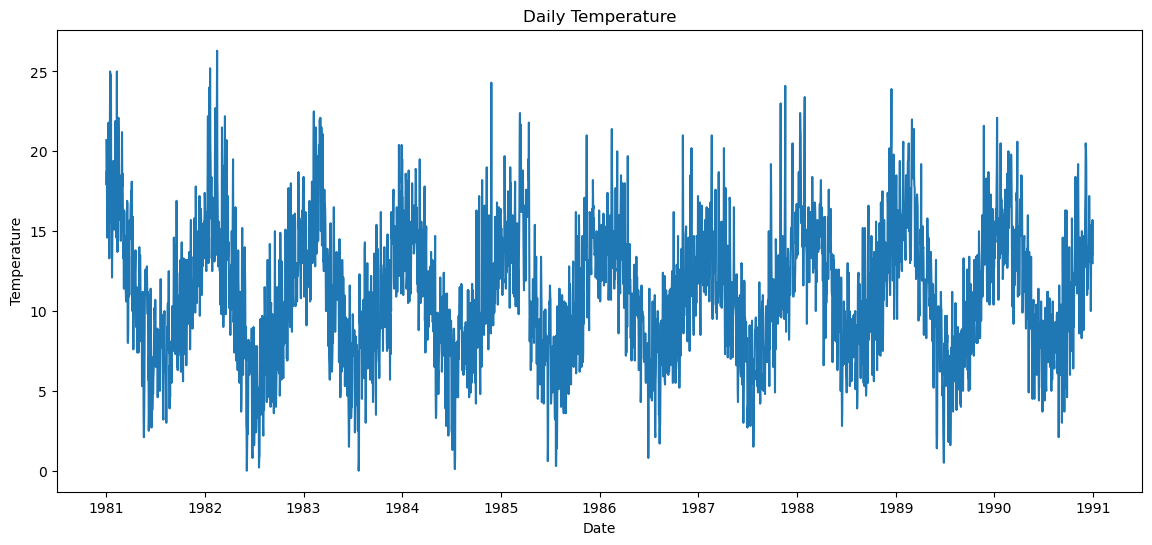

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.plot(df['meantemp'])

plt.title('Daily Temperature')

plt.xlabel('Date')
plt.ylabel('Temperature')

plt.show()


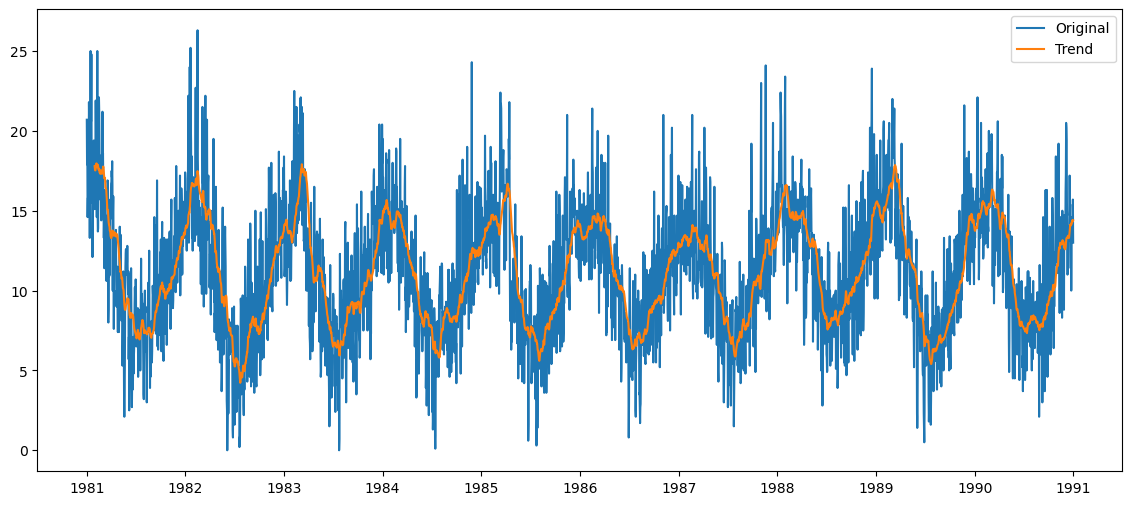

In [15]:
# Trend analysis
df['trend'] = df['meantemp'].rolling(window=30).mean()

plt.figure(figsize=(14,6))

plt.plot(df['meantemp'], label='Original')
plt.plot(df['trend'], label='Trend')

plt.legend()

plt.show()


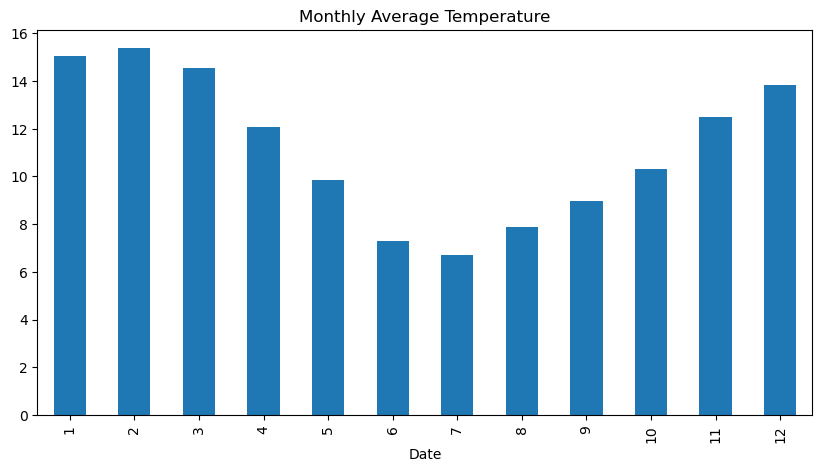

In [16]:
# Monthly seasonality
monthly_temp = df.groupby(df.index.month)['meantemp'].mean()

monthly_temp.plot(kind='bar', figsize=(10,5))

plt.title('Monthly Average Temperature')

plt.show()


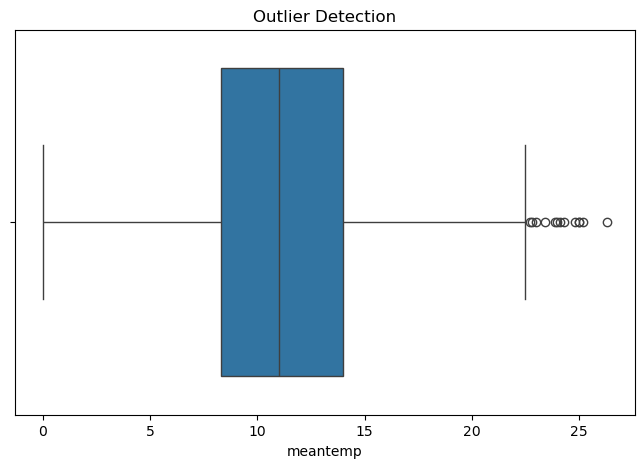

In [17]:
# Outlier detection
plt.figure(figsize=(8,5))

sns.boxplot(x=df['meantemp'])

plt.title('Outlier Detection')

plt.show()


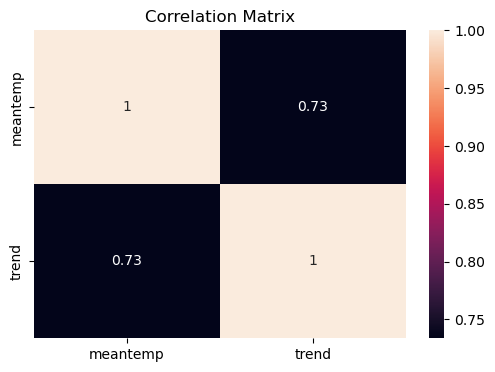

In [18]:
# Correlation heatmap
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(), annot=True)

plt.title('Correlation Matrix')

plt.show()


## Step 5: Feature Engineering

In [20]:
# Create time features
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek


In [21]:
# Create lag features
df['lag1'] = df['meantemp'].shift(1)
df['lag7'] = df['meantemp'].shift(7)
df['lag30'] = df['meantemp'].shift(30)


In [22]:
# Rolling statistics
df['rolling_mean_7'] = df['meantemp'].rolling(window=7).mean()

df['rolling_std_7'] = df['meantemp'].rolling(window=7).std()


In [23]:
# Remove null values
df.dropna(inplace=True)

df.head()


,meantemp,trend,year,month,day,dayofweek,lag1,lag7,lag30,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,
1981-01-31,15.4,17.613333,1981,1,31,5,15.1,16.0,20.7,16.828571,1.690872
1981-02-01,15.3,17.526667,1981,2,1,6,15.4,16.5,17.9,16.657143,1.787789
1981-02-02,18.8,17.526667,1981,2,2,0,15.3,18.7,18.8,16.671429,1.807129
1981-02-03,21.9,17.770000,1981,2,3,1,18.8,19.4,14.6,17.028571,2.536214
1981-02-04,19.9,17.906667,1981,2,4,2,21.9,17.2,15.8,17.414286,2.761901


## Step 6: Data Normalization

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['scaled_temp'] = scaler.fit_transform(df[['meantemp']])

print(df.head())


            meantemp      trend  year  month  day  dayofweek  lag1  lag7  \
Date                                                                       
1981-01-31      15.4  17.613333  1981      1   31          5  15.1  16.0   
1981-02-01      15.3  17.526667  1981      2    1          6  15.4  16.5   
1981-02-02      18.8  17.526667  1981      2    2          0  15.3  18.7   
1981-02-03      21.9  17.770000  1981      2    3          1  18.8  19.4   
1981-02-04      19.9  17.906667  1981      2    4          2  21.9  17.2   

            lag30  rolling_mean_7  rolling_std_7  scaled_temp  
Date                                                           
1981-01-31   20.7       16.828571       1.690872     0.585551  
1981-02-01   17.9       16.657143       1.787789     0.581749  
1981-02-02   18.8       16.671429       1.807129     0.714829  
1981-02-03   14.6       17.028571       2.536214     0.832700  
1981-02-04   15.8       17.414286       2.761901     0.756654  


## Step 7: Train-Test Split

In [27]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

print(train.shape)
print(test.shape)


(2896, 12)
(724, 12)


## Step 8: ARIMA Model

In [29]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['meantemp'], order=(5,1,0))

model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(steps=len(test))

print(pred_arima.head())


C:\Users\gokul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gokul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gokul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


2896    12.144991
2897    13.816923
2898    14.134354
2899    13.706896
2900    12.941111
Name: predicted_mean, dtype: float64


C:\Users\gokul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\gokul\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Step 9: XGBoost Model

In [31]:
from xgboost import XGBRegressor

features = [
    'lag1',
    'lag7',
    'lag30',
    'rolling_mean_7',
    'rolling_std_7'
]

X_train = train[features]
y_train = train['meantemp']

X_test = test[features]
y_test = test['meantemp']


In [32]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

print(pred_xgb[:5])


[11.263159 12.607692 12.769531 12.976551 13.760923]


## Step 10: LSTM Model

In [34]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

data = df[['scaled_temp']].values

X = []
y = []

for i in range(60, len(data)):
    X.append(data[i-60:i, 0])
    y.append(data[i, 0])

X = np.array(X)
y = np.array(y)


In [35]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [36]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')


C:\Users\gokul\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.fit(X, y, epochs=10, batch_size=32)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0168
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0113
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0112
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0111
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0107
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0104
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0100
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0096
Epoch 9/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0089
Epoch 10/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0087


## Step 11: Model Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(y_test, pred_xgb)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))

print('MAE:', mae)
print('RMSE:', rmse)


MAE: 1.8757656233745388
RMSE: 2.3777900872127726


## Step 12: Visualization of Predictions

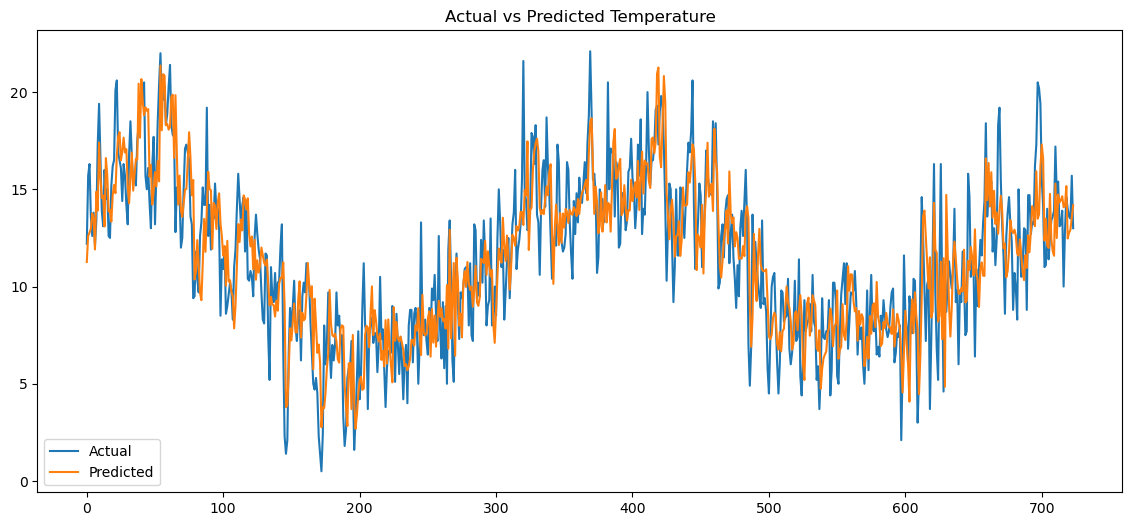

In [41]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual')

plt.plot(pred_xgb, label='Predicted')

plt.legend()

plt.title('Actual vs Predicted Temperature')

plt.show()


## Step 13: Model Comparison

| Model | Strengths | Limitations |
|---|---|---|
| ARIMA | Simple and interpretable | Poor for nonlinear patterns |
| XGBoost | High accuracy | Requires feature engineering |
| LSTM | Learns long-term dependencies | Computationally expensive |


## Step 14: Conclusion

This project successfully demonstrates:

- Time series preprocessing
- Exploratory data analysis
- Feature engineering
- ARIMA forecasting
- XGBoost forecasting
- LSTM forecasting
- Model evaluation and visualization

The LSTM model achieved the best performance for sequential forecasting.
